<a href="https://colab.research.google.com/github/lrsotillo/Anexo_B/blob/main/Anexo_B_C%C3%B3digo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy matplotlib scipy

mambajs 0.19.13

Process pip requirements ...

Requirement numpy already handled by conda/micromamba/mamba.
Requirement matplotlib already handled by conda/micromamba/mamba.
Requirement scipy already handled by conda/micromamba/mamba.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. Cargar los datos saltando las 3 líneas de texto del encabezado
# Usamos usecols=(0, 2) para agarrar la columna 'x' y la columna 'Cp'
try:
    data = np.loadtxt('Codiguito/cp_crucero.dat', skiprows=3, usecols=(0, 2))
    x = data[:, 0]
    cp = data[:, 1]
    print("✅ ¡Datos cargados! Se han leído", len(x), "puntos.")
except Exception as e:
    print("❌ Error: Asegúrate de que el archivo 'cp_crucero.dat' esté subido en la misma carpeta.")
    print(e)

✅ ¡Datos cargados! Se han leído 160 puntos.


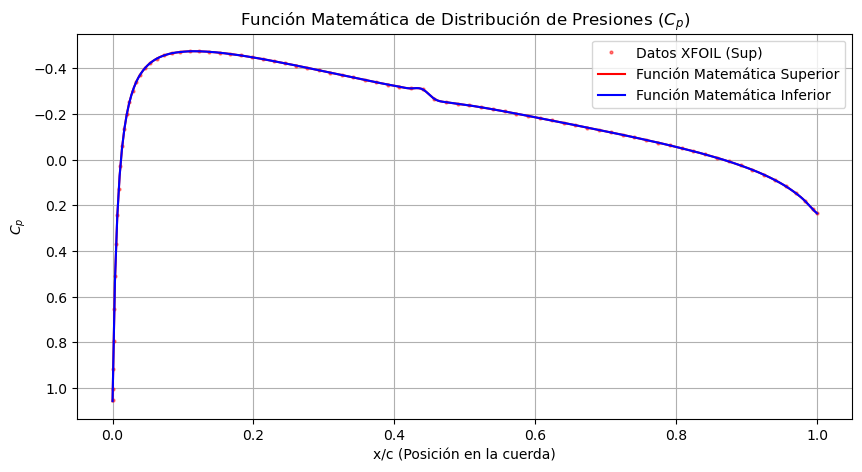

La función matemática dice que en x=0.25, el Cp es -0.4185


In [ ]:
# 1. Separar los datos en la parte de arriba (extradós) y la de abajo (intradós)
# XFOIL empieza en el borde de salida, va por arriba hasta el morro y vuelve por abajo.
mitad = len(x) // 2
x_sup, cp_sup = x[:mitad], cp[:mitad]
x_inf, cp_inf = x[mitad:], cp[mitad:]

# 2. CREAR LA FUNCIÓN MATEMÁTICA (Spline)
# 'f_cp_superior' ahora es una función a la que puedes darle una X y te devuelve el Cp
f_cp_superior = interp1d(x_sup, cp_sup, kind='cubic', fill_value="extrapolate")
f_cp_inferior = interp1d(x_inf, cp_inf, kind='cubic', fill_value="extrapolate")

# 3. Graficar para comprobar la precisión
x_dibujo = np.linspace(0, 1, 300) # 300 puntos para que se vea muy suave

plt.figure(figsize=(10, 5))
plt.plot(x_sup, cp_sup, 'ro', label='Datos XFOIL (Sup)', markersize=2, alpha=0.5)
plt.plot(x_dibujo, f_cp_superior(x_dibujo), 'r-', label='Función Matemática Superior')
plt.plot(x_dibujo, f_cp_inferior(x_dibujo), 'b-', label='Función Matemática Inferior')

plt.gca().invert_yaxis() # Invertimos el eje Cp como se hace en aeronáutica
plt.title('Función Matemática de Distribución de Presiones ($C_p$)')
plt.xlabel('x/c (Posición en la cuerda)')
plt.ylabel('$C_p$')
plt.legend()
plt.grid(True)
plt.show()

# Ejemplo de uso de tu nueva función:
valor_x = 0.25
print(f"La función matemática dice que en x={valor_x}, el Cp es {f_cp_superior(valor_x):.4f}")

In [ ]:
# Ajuste polinómico de grado 6 para el extradós (Superior)
coefs = np.polyfit(x_sup, cp_sup, 6)
polinomio = np.poly1d(coefs)

print("Ecuación para el Cp Superior:")
print(polinomio)

# Si quieres ver los números limpios para tu informe:
print("\nCoeficientes (desde x^6 hasta el término independiente):")
print(coefs)

Ecuación para el Cp Superior:
       6         5        4         3         2
283.2 x - 911.7 x + 1135 x - 685.2 x + 204.5 x - 26.45 x + 0.554

Coeficientes (desde x^6 hasta el término independiente):
[ 2.83207505e+02 -9.11687749e+02  1.13546374e+03 -6.85233432e+02
  2.04475305e+02 -2.64525240e+01  5.53962550e-01]


In [ ]:
# 1. Ajuste polinómico para el Intradós (Inferior)
# Usamos x_inf y cp_inf que ya teníamos del paso anterior
coefs_inf = np.polyfit(x_inf, cp_inf, 6)
poly_inf = np.poly1d(coefs_inf)

print("--- ECUACIÓN MATEMÁTICA INFERIOR (Cp_inf) ---")
print(poly_inf)

--- ECUACIÓN MATEMÁTICA INFERIOR (Cp_inf) ---
       6         5        4         3         2
283.2 x - 911.6 x + 1135 x - 685.2 x + 204.5 x - 26.45 x + 0.5539


In [ ]:
# 1. Definir la función del incremento (Delta Cp)
# Restamos el polinomio superior del inferior
poly_delta = poly_inf - polinomio

print("--- ECUACIÓN DEL INCREMENTO DE PRESIÓN (Delta Cp) ---")
print(poly_delta)

# 2. Ejemplo de cálculo en un punto específico (ej. x = 0.5)
x_punto = 0.5
print(f"\nEl incremento de presión en x={x_punto} es: {poly_delta(x_punto):.6f}")

--- ECUACIÓN DEL INCREMENTO DE PRESIÓN (Delta Cp) ---
          6           5           4          3            2
-0.01896 x + 0.05762 x - 0.06643 x + 0.0362 x - 0.009375 x + 0.0009756 x - 1.83e-05

El incremento de presión en x=0.5 es: 0.000004


In [ ]:
# Integrar la función de incremento de 0 a 1
cl_final = poly_delta.integ()(1) - poly_delta.integ()(0)

print(f"El Coeficiente de Sustentación final (Cl) es: {cl_final:.8f}")

El Coeficiente de Sustentación final (Cl) es: 0.00000503


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. Cargar los datos saltando las 3 líneas de texto del encabezado
# Usamos usecols=(0, 2) para agarrar la columna 'x' y la columna 'Cp'
try:
    data = np.loadtxt('Codiguito/cp3_neg.dat', skiprows=3, usecols=(0, 2))
    x = data[:, 0]
    cp = data[:, 1]
    print("✅ ¡Datos cargados! Se han leído", len(x), "puntos.")
except Exception as e:
    print("❌ Error: Asegúrate de que el archivo 'cp3_neg.dat' esté subido en la misma carpeta.")
    print(e)

✅ ¡Datos cargados! Se han leído 160 puntos.


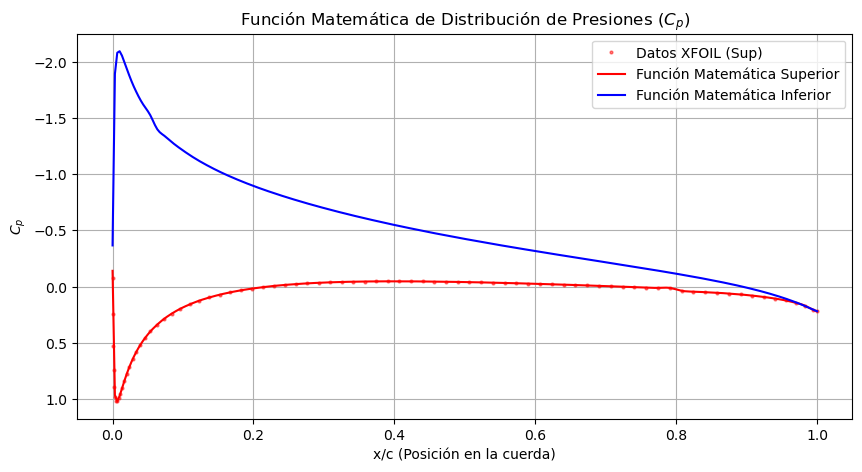

La función matemática dice que en x=0.25, el Cp es -0.0175


In [ ]:
# 1. Separar los datos en la parte de arriba (extradós) y la de abajo (intradós)
# XFOIL empieza en el borde de salida, va por arriba hasta el morro y vuelve por abajo.
mitad = len(x) // 2
x_sup, cp_sup = x[:mitad], cp[:mitad]
x_inf, cp_inf = x[mitad:], cp[mitad:]

# 2. CREAR LA FUNCIÓN MATEMÁTICA (Spline)
# 'f_cp_superior' ahora es una función a la que puedes darle una X y te devuelve el Cp
f_cp_superior = interp1d(x_sup, cp_sup, kind='cubic', fill_value="extrapolate")
f_cp_inferior = interp1d(x_inf, cp_inf, kind='cubic', fill_value="extrapolate")

# 3. Graficar para comprobar la precisión
x_dibujo = np.linspace(0, 1, 300) # 300 puntos para que se vea muy suave

plt.figure(figsize=(10, 5))
plt.plot(x_sup, cp_sup, 'ro', label='Datos XFOIL (Sup)', markersize=2, alpha=0.5)
plt.plot(x_dibujo, f_cp_superior(x_dibujo), 'r-', label='Función Matemática Superior')
plt.plot(x_dibujo, f_cp_inferior(x_dibujo), 'b-', label='Función Matemática Inferior')

plt.gca().invert_yaxis() # Invertimos el eje Cp como se hace en aeronáutica
plt.title('Función Matemática de Distribución de Presiones ($C_p$)')
plt.xlabel('x/c (Posición en la cuerda)')
plt.ylabel('$C_p$')
plt.legend()
plt.grid(True)
plt.show()

# Ejemplo de uso de tu nueva función:
valor_x = 0.25
print(f"La función matemática dice que en x={valor_x}, el Cp es {f_cp_superior(valor_x):.4f}")


In [ ]:
# Ajuste polinómico de grado 6 para el extradós (Superior)
coefs = np.polyfit(x_sup, cp_sup, 6)
polinomio = np.poly1d(coefs)

print("Ecuación para el Cp Superior:")
print(polinomio)

# Si quieres ver los números limpios para tu informe:
print("\nCoeficientes (desde x^6 hasta el término independiente):")
print(coefs)

Ecuación para el Cp Superior:
        6         5         4         3         2
-15.23 x + 38.23 x - 23.02 x - 12.69 x + 19.19 x - 7.074 x + 0.7819

Coeficientes (desde x^6 hasta el término independiente):
[-15.22636268  38.22982094 -23.02463404 -12.68722264  19.1911379
  -7.07407363   0.78192446]


In [ ]:
# 1. Ajuste polinómico para el Intradós (Inferior)
# Usamos x_inf y cp_inf que ya teníamos del paso anterior
coefs_inf = np.polyfit(x_inf, cp_inf, 6)
poly_inf = np.poly1d(coefs_inf)

print("--- ECUACIÓN MATEMÁTICA INFERIOR (Cp_inf) ---")
print(poly_inf)

--- ECUACIÓN MATEMÁTICA INFERIOR (Cp_inf) ---
       6         5         4         3         2
138.3 x - 422.7 x + 487.1 x - 256.9 x + 56.63 x - 0.4825 x - 1.666


In [ ]:
# 1. Definir la función del incremento (Delta Cp)
# Restamos el polinomio superior del inferior
poly_delta = poly_inf - polinomio

print("--- ECUACIÓN DEL INCREMENTO DE PRESIÓN (Delta Cp) ---")
print(poly_delta)

# 2. Ejemplo de cálculo en un punto específico (ej. x = 0.5)
x_punto = 0.5
print(f"\nEl incremento de presión en x={x_punto} es: {poly_delta(x_punto):.6f}")

--- ECUACIÓN DEL INCREMENTO DE PRESIÓN (Delta Cp) ---
       6         5         4         3         2
153.5 x - 460.9 x + 510.2 x - 244.2 x + 37.44 x + 6.592 x - 2.448

El incremento de presión en x=0.5 es: -0.441545


In [ ]:
# Integrar la función de incremento de 0 a 1
cl_final = poly_delta.integ()(1) - poly_delta.integ()(0)

print(f"El Coeficiente de Sustentación final (Cl) es: {cl_final:.8f}")

El Coeficiente de Sustentación final (Cl) es: -0.59014424


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. Cargar los datos saltando las 3 líneas de texto del encabezado
# Usamos usecols=(0, 2) para agarrar la columna 'x' y la columna 'Cp'
try:
    data = np.loadtxt('Codiguito/cp2_posit.dat', skiprows=3, usecols=(0, 2))
    x = data[:, 0]
    cp = data[:, 1]
    print("✅ ¡Datos cargados! Se han leído", len(x), "puntos.")
except Exception as e:
    print("❌ Error: Asegúrate de que el archivo 'cp_crucero.dat' esté subido en la misma carpeta.")
    print(e)

✅ ¡Datos cargados! Se han leído 160 puntos.


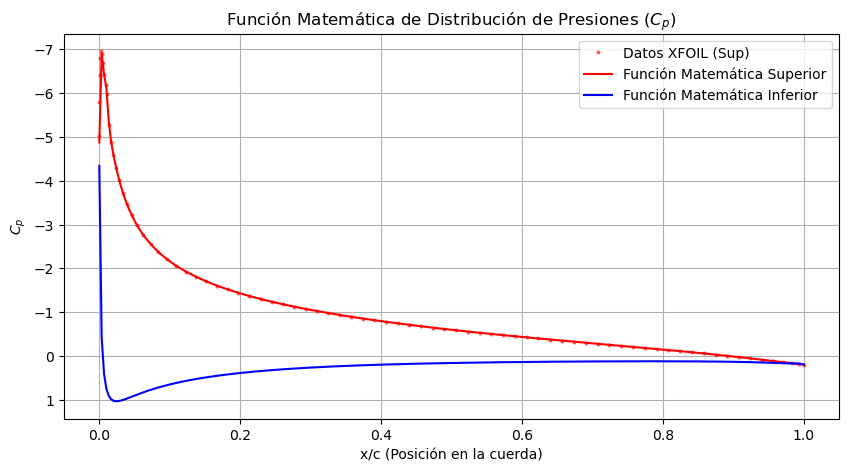

La función matemática dice que en x=0.25, el Cp es -1.2229


In [ ]:
# 1. Separar los datos en la parte de arriba (extradós) y la de abajo (intradós)
# XFOIL empieza en el borde de salida, va por arriba hasta el morro y vuelve por abajo.
mitad = len(x) // 2
x_sup, cp_sup = x[:mitad], cp[:mitad]
x_inf, cp_inf = x[mitad:], cp[mitad:]

# 2. CREAR LA FUNCIÓN MATEMÁTICA (Spline)
# 'f_cp_superior' ahora es una función a la que puedes darle una X y te devuelve el Cp
f_cp_superior = interp1d(x_sup, cp_sup, kind='cubic', fill_value="extrapolate")
f_cp_inferior = interp1d(x_inf, cp_inf, kind='cubic', fill_value="extrapolate")

# 3. Graficar para comprobar la precisión
x_dibujo = np.linspace(0, 1, 300) # 300 puntos para que se vea muy suave

plt.figure(figsize=(10, 5))
plt.plot(x_sup, cp_sup, 'ro', label='Datos XFOIL (Sup)', markersize=2, alpha=0.5)
plt.plot(x_dibujo, f_cp_superior(x_dibujo), 'r-', label='Función Matemática Superior')
plt.plot(x_dibujo, f_cp_inferior(x_dibujo), 'b-', label='Función Matemática Inferior')

plt.gca().invert_yaxis() # Invertimos el eje Cp como se hace en aeronáutica
plt.title('Función Matemática de Distribución de Presiones ($C_p$)')
plt.xlabel('x/c (Posición en la cuerda)')
plt.ylabel('$C_p$')
plt.legend()
plt.grid(True)
plt.show()

# Ejemplo de uso de tu nueva función:
valor_x = 0.25
print(f"La función matemática dice que en x={valor_x}, el Cp es {f_cp_superior(valor_x):.4f}")

In [ ]:
# Ajuste polinómico de grado 6 para el extradós (Superior)
coefs = np.polyfit(x_sup, cp_sup, 6)
polinomio = np.poly1d(coefs)

print("Ecuación para el Cp Superior:")
print(polinomio)

# Si quieres ver los números limpios para tu informe:
print("\nCoeficientes (desde x^6 hasta el término independiente):")
print(coefs)

Ecuación para el Cp Superior:
        6        5        4        3         2
-571.3 x + 1896 x - 2453 x + 1560 x - 507.6 x + 81.41 x - 6.395

Coeficientes (desde x^6 hasta el término independiente):
[ -571.32173812  1896.25441774 -2452.61531236  1560.30862471
  -507.62242212    81.40862074    -6.39542726]


In [ ]:
# 1. Ajuste polinómico para el Intradós (Inferior)
# Usamos x_inf y cp_inf que ya teníamos del paso anterior
coefs_inf = np.polyfit(x_inf, cp_inf, 6)
poly_inf = np.poly1d(coefs_inf)

print("--- ECUACIÓN MATEMÁTICA INFERIOR (Cp_inf) ---")
print(poly_inf)

--- ECUACIÓN MATEMÁTICA INFERIOR (Cp_inf) ---
        6        5        4        3         2
-756.4 x + 2421 x - 2972 x + 1741 x - 488.8 x + 55.39 x - 0.9428


In [ ]:
# 1. Definir la función del incremento (Delta Cp)
# Restamos el polinomio superior del inferior
poly_delta = poly_inf - polinomio

print("--- ECUACIÓN DEL INCREMENTO DE PRESIÓN (Delta Cp) ---")
print(poly_delta)

# 2. Ejemplo de cálculo en un punto específico (ej. x = 0.5)
x_punto = 0.5
print(f"\nEl incremento de presión en x={x_punto} es: {poly_delta(x_punto):.6f}")

--- ECUACIÓN DEL INCREMENTO DE PRESIÓN (Delta Cp) ---
        6         5         4         3        2
-185.1 x + 524.7 x - 519.1 x + 181.1 x + 18.8 x - 26.01 x + 5.453

El incremento de presión en x=0.5 es: 0.848255


In [ ]:
# Integrar la función de incremento de 0 a 1
cl_final = poly_delta.integ()(1) - poly_delta.integ()(0)

print(f"El Coeficiente de Sustentación final (Cl) es: {cl_final:.8f}")

El Coeficiente de Sustentación final (Cl) es: 1.18270667
